In [2]:
# ==============================
# 8. FINANCIAL ANALYSIS
# ==============================

import pandas as pd

# Load dataset
df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Convert TotalCharges safely
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# ==============================
# 1. Overall Revenue Overview
# ==============================
print("\n--- Monthly Charges Summary ---")
print(df['MonthlyCharges'].describe())

print("\n--- Total Charges Summary ---")
print(df['TotalCharges'].describe())

# ==============================
# 2. Revenue by Churn Status
# ==============================
print("\n--- Revenue by Churn Status ---")
print(df.groupby('Churn')[['MonthlyCharges', 'TotalCharges']].mean())

print("\n--- Median Revenue by Churn Status ---")
print(df.groupby('Churn')[['MonthlyCharges', 'TotalCharges']].median())

# ==============================
# 3. Revenue by Contract Type
# ==============================
print("\n--- Revenue by Contract Type (Mean) ---")
print(df.groupby('Contract')[['MonthlyCharges', 'TotalCharges']].mean())

print("\n--- Revenue by Contract Type (Median) ---")
print(df.groupby('Contract')[['MonthlyCharges', 'TotalCharges']].median())

# ==============================
# 4. High Value vs Low Value Customers
# (Based on TotalCharges median split)
# ==============================
median_value = df['TotalCharges'].median()

df['CustomerSegment'] = df['TotalCharges'].apply(
    lambda x: 'High Value' if x >= median_value else 'Low Value'
)

print("\n--- Customer Segmentation (Value-Based) ---")
print(df['CustomerSegment'].value_counts())

print("\nPercentage:")
print(df['CustomerSegment'].value_counts(normalize=True) * 100)

# ==============================
# 5. Revenue by Customer Segment
# ==============================
print("\n--- Revenue by Customer Segment ---")
print(df.groupby('CustomerSegment')[['MonthlyCharges', 'TotalCharges']].mean())

# ==============================
# 6. Churn Impact on Revenue Loss
# ==============================
print("\n--- Estimated Revenue Loss from Churned Customers ---")
print(df[df['Churn'] == 'Yes'][['MonthlyCharges', 'TotalCharges']].sum())

# ==============================
# 7. Overall Dataset Summary
# ==============================
print("\n--- Dataset Summary ---")
print("Total Customers:", df.shape[0])
print("Total Features:", df.shape[1])


--- Monthly Charges Summary ---
count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64

--- Total Charges Summary ---
count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

--- Revenue by Churn Status ---
       MonthlyCharges  TotalCharges
Churn                              
No          61.265124   2555.344141
Yes         74.441332   1531.796094

--- Median Revenue by Churn Status ---
       MonthlyCharges  TotalCharges
Churn                              
No             64.425       1683.60
Yes            79.650        703.55

--- Revenue by Contract Type (Mean) ---
                MonthlyCharges  TotalCharges
Contract                                    
Month-to-month       66.398490   136

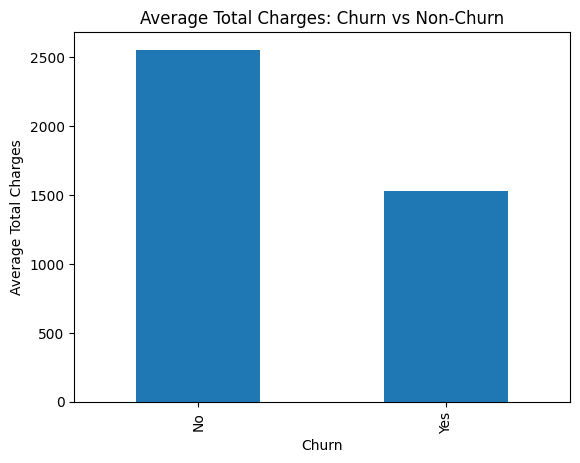

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df.groupby('Churn')['TotalCharges'].mean().plot(kind='bar')

plt.title('Average Total Charges: Churn vs Non-Churn')
plt.xlabel('Churn')
plt.ylabel('Average Total Charges')
plt.show()